# The Kernel Trick

This notebook verifies the central kernel idea from Lecture 6: an inner product in an expanded feature space can sometimes be computed directly from the original inputs.

## 1. Explicit polynomial feature map

For two-dimensional inputs, define the feature map corresponding exactly to the degree-two polynomial kernel $(1+x^Tz)^2$:

$$\phi(x_1,x_2) = (1,\;\sqrt{2}x_1,\;\sqrt{2}x_2,\;x_1^2,\;x_2^2,\;\sqrt{2}x_1x_2).$$

Then $\phi(x)^T\phi(z)=(1+x^Tz)^2$.

In [1]:
import numpy as np

def phi(x):
    x1, x2 = x
    return np.array([1.0, np.sqrt(2) * x1, np.sqrt(2) * x2, x1**2, x2**2, np.sqrt(2) * x1 * x2])

x = np.array([1.5, -0.5])
z = np.array([-0.25, 2.0])

explicit_inner_product = phi(x) @ phi(z)
dot = x @ z
kernel_value = (1 + dot)**2

print('phi(x) =', phi(x))
print('phi(z) =', phi(z))
print('Explicit feature-space inner product:', explicit_inner_product)
print('Polynomial kernel:', kernel_value)
print('Difference:', abs(explicit_inner_product - kernel_value))
assert np.allclose(explicit_inner_product, kernel_value)

phi(x) = [ 1.          2.12132034 -0.70710678  2.25        0.25       -1.06066017]
phi(z) = [ 1.         -0.35355339  2.82842712  0.0625      4.         -0.70710678]
Explicit feature-space inner product: 0.14062499999999967
Polynomial kernel: 0.140625
Difference: 3.3306690738754696e-16


The two values agree up to floating-point precision. The important point is not the particular polynomial: it is that the high-dimensional inner product can be evaluated without explicitly constructing the expanded vectors.

## 2. Compare explicit features with the kernel

A kernel is defined by

$$K(x,z)=\phi(x)^T\phi(z).$$

For the map above, the corresponding kernel is

$$K(x,z)=(1+x^Tz)^2.$$

The kernel computation needs only the original dot product and a small amount of scalar arithmetic.

In [2]:
def polynomial_kernel(X, Z, degree=2):
    return (1 + X @ Z) ** degree

X = np.array([[1, 2], [2, 1], [-1, -1], [0.5, 1.5]])
Z = np.array([[0.5, -1], [1.0, 1.0]])

K = polynomial_kernel(X, Z, degree=2)
print(K)

[[12.25    4.    ]
 [ 9.      0.    ]
 [ 0.25    1.    ]
 [ 7.5625  4.    ]]


## 3. A higher-order kernel

The same idea can be extended. Polynomial kernels of the form

$$K(x,z)=(1+x^Tz)^p$$

correspond to increasingly rich polynomial feature representations. The feature dimension can grow very quickly, while evaluating the kernel still requires only the original dot product followed by a power.

In [3]:
degrees = [1, 2, 3, 5, 10]
dot = x @ z

for p in degrees:
    print(f'degree={p:2d}: K(x,z)={(1 + dot)**p:.6f}')

degree= 1: K(x,z)=-0.375000
degree= 2: K(x,z)=0.140625
degree= 3: K(x,z)=-0.052734
degree= 5: K(x,z)=-0.007416
degree=10: K(x,z)=0.000055


## 4. Choosing the polynomial degree

The degree $p$ is not a value that the kernel trick determines automatically. It is a **hyperparameter**: we choose a set of candidate values and use validation or cross-validation to decide which one generalizes best.

The reason is that $p$ controls the complexity of the implicit feature representation. Larger degrees allow richer polynomial interactions, but greater flexibility does not guarantee better performance on unseen data.

A typical model-selection workflow is:

1. choose candidate degrees, such as $p \in \{1,2,3,4,5\}$;
2. train the classifier using each degree;
3. evaluate each model on validation data or with cross-validation;
4. choose the degree with the best validation performance;
5. retrain the selected model on the available training data before the final test evaluation.

In notation, if $S_{\mathrm{val}}(p)$ is the validation score for degree $p$, then we choose

$$p^* = \arg\max_p S_{\mathrm{val}}(p)$$

The kernel trick makes evaluating different degrees inexpensive with respect to feature construction: for each candidate $p$, we can compute $(1+x^Tz)^p$ directly instead of explicitly constructing the corresponding polynomial feature vectors.

This connects the kernel trick to the model-selection idea introduced earlier in the course: **the learning algorithm fits the model, while validation selects the hyperparameters that control the model.**

The examples above use degrees $1,2,3,5,10$ only to illustrate how the kernel value changes. Those values are not a claim that one degree is universally best; the appropriate degree depends on the dataset and should be selected using validation.

### Model-selection experiment

We can now demonstrate the selection rule on a small nonlinear dataset. We use cross-validation to estimate $S_{\mathrm{val}}(p)$ for several candidate degrees. The fixed random seeds make the experiment reproducible, but the resulting $p^*$ is specific to this dataset and is not a universally optimal degree.

In [4]:
import numpy as np

# Build a small two-moons dataset using NumPy so the first experiment
# does not depend on a machine-learning library.
rng = np.random.default_rng(42)
n_samples = 300
n_half = n_samples // 2
angles = np.linspace(0, np.pi, n_half, endpoint=False)
noise = 0.2

moon_1 = np.column_stack((np.cos(angles), np.sin(angles)))
moon_2 = np.column_stack((1 - np.cos(angles), 0.5 - np.sin(angles)))
X = np.vstack((moon_1, moon_2)) + rng.normal(0, noise, (n_samples, 2))
y = np.concatenate((np.ones(n_half, dtype=int), np.zeros(n_half, dtype=int)))

# Keep a final test set aside before model selection.
test_size = 60
permutation = rng.permutation(n_samples)
test_idx = permutation[:test_size]
train_idx = permutation[test_size:]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
y_train_pm = 2 * y_train - 1

def polynomial_kernel_matrix(A, B, degree):
    return (1 + A @ B.T) ** degree

def kernel_perceptron(X, y, degree, epochs=10):
    K = polynomial_kernel_matrix(X, X, degree)
    alpha = np.zeros(len(X), dtype=int)

    for _ in range(epochs):
        for i in range(len(X)):
            score = np.sum(alpha * y * K[:, i])
            if y[i] * score <= 0:
                alpha[i] += 1

    return alpha

def stratified_folds(y, n_folds=5):
    folds = [[] for _ in range(n_folds)]
    for label in np.unique(y):
        indices = np.flatnonzero(y == label)
        for i, index in enumerate(indices):
            folds[i % n_folds].append(index)
    return [np.array(sorted(fold)) for fold in folds]

folds = stratified_folds(y_train, n_folds=5)
degrees = list(range(1, 11))
validation_scores = []

for p in degrees:
    fold_scores = []

    for fold in folds:
        val_idx = fold
        train_idx = np.concatenate([f for f in folds if f is not fold])

        alpha = kernel_perceptron(
            X_train[train_idx], y_train_pm[train_idx], degree=p, epochs=10
        )
        K_val = polynomial_kernel_matrix(
            X_train[train_idx], X_train[val_idx], degree=p
        )
        scores = K_val.T @ (alpha * y_train_pm[train_idx])
        predictions = np.where(scores >= 0, 1, -1)
        fold_scores.append(np.mean(predictions == y_train_pm[val_idx]))

    validation_scores.append(np.mean(fold_scores))

best_index = int(np.argmax(validation_scores))
best_degree = degrees[best_index]
best_score = validation_scores[best_index]

print('Best degree with our Kernel Perceptron:', best_degree)
print(f'Best mean validation accuracy: {best_score:.3f}')


Best degree with our Kernel Perceptron: 3
Best mean validation accuracy: 0.937


### What is the validation score?

For one fold, the validation score is the fraction of validation examples classified correctly:

$$S_k(p)=\\frac{1}{|V_k|}\\sum_{i\\in V_k}\\mathbf{1}\\{\\hat y_i=y_i\\}.$$
We repeat this for five folds and average the five scores:

$$S_{\\mathrm{val}}(p)=\\frac{1}{5}\\sum_{k=1}^{5}S_k(p).$$
The code above computes this procedure **without using an external classifier**. It uses the Kernel Perceptron and the polynomial kernel introduced in the course. For this experiment, our Kernel Perceptron selects $p=3$ with mean validation accuracy $0.937$.

This result belongs to the learning algorithm being evaluated: changing the learning algorithm can change which hyperparameter performs best.

### Now use external machine-learning libraries

Only after completing the experiment with the methods we learned, we can use scikit-learn to perform the same kind of model-selection task with an SVM.

Here the external library provides both the learning algorithm (`SVC`) and the cross-validation utility (`cross_val_score`). This is deliberately separated from the implementation above so that the role of the library is clear.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC

sklearn_scores = []
cv = StratifiedKFold(n_splits=5, shuffle=False)

for p in degrees:
    model = SVC(kernel='poly', degree=p, coef0=1, C=1)
    scores = cross_val_score(model, X_train, y_train, cv=cv)
    sklearn_scores.append(scores.mean())

sklearn_best_index = int(np.argmax(sklearn_scores))
sklearn_best_degree = degrees[sklearn_best_index]
sklearn_best_score = sklearn_scores[sklearn_best_index]

print('Best degree with sklearn SVC:', sklearn_best_degree)
print(f'Best mean validation accuracy: {sklearn_best_score:.3f}')
print('\nThe methods use different learning algorithms, so their best degrees need not be the same.')


Best degree with sklearn SVC: 4
Best mean validation accuracy: 0.967

The methods use different learning algorithms, so their best degrees need not be the same.


The external-library section is intentionally separate. The first experiment shows what the learning algorithm, kernel, folds, predictions, and validation score actually are. The second section shows how a library can provide those building blocks in a compact interface.

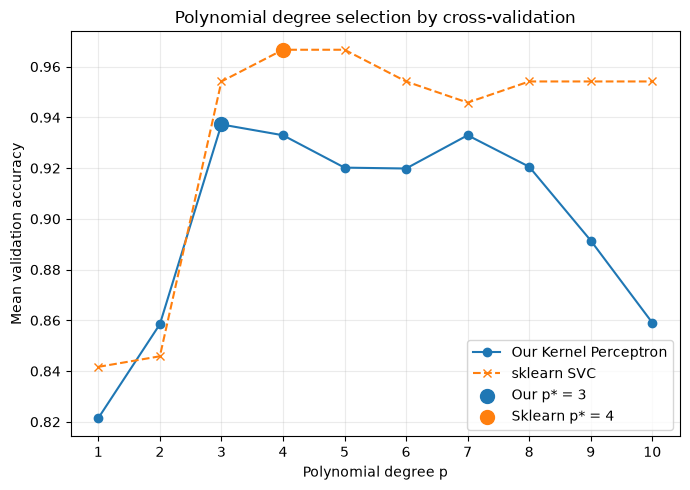

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(degrees, validation_scores, marker='o', label='Our Kernel Perceptron')
plt.plot(degrees, sklearn_scores, marker='x', linestyle='--', label='sklearn SVC')
plt.scatter([best_degree], [best_score], s=100, zorder=3, label=f'Our p* = {best_degree}')
plt.scatter([sklearn_best_degree], [sklearn_best_score], s=100, zorder=3, label=f'Sklearn p* = {sklearn_best_degree}')
plt.xlabel('Polynomial degree p')
plt.ylabel('Mean validation accuracy')
plt.title('Polynomial degree selection by cross-validation')
plt.xticks(degrees)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


The highest point on the curve gives the selected degree:

$$p^* = \arg\max_p S_{\mathrm{val}}(p).$$

The plot makes the model-selection step concrete: $p$ is chosen from the candidate values using validation performance, rather than being fixed by the kernel trick itself.

### Takeaway

The kernel trick is a computational shortcut:

$$\phi(x)^T\phi(z) \;\longrightarrow\; K(x,z)$$

We first implemented the complete experiment ourselves using NumPy and the Kernel Perceptron derived in the course. This gave $p^*=3$ for this experiment. Only afterward did we introduce scikit-learn, where `SVC` and `cross_val_score` gave $p^*=4$.

The different choices are expected because Kernel Perceptron and SVM are different learning algorithms. The important lesson is to understand the method before relying on a library implementation.